# Quantum Simulation — S1 to S6
Reproduces all figures from the Supporting Information PDF.

In [29]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import io

def show(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    display(Image(buf.read()))
    plt.close(fig)

n_draw = 4  # jumlah qubit untuk gambar circuit (kecil agar terbaca)


## Figure S1 — Potential energy operator: double-well
Konstanta: `V_min = -0.017`, `dt = t_fin/N = 300/100 = 3.0`

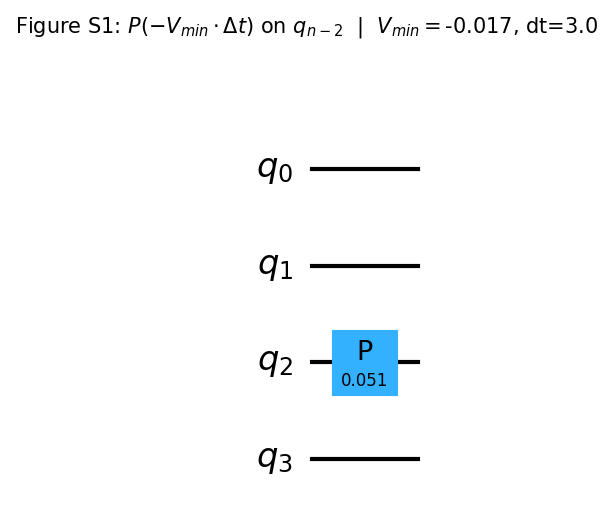

In [30]:
# Konstanta tunneling (dari PDF S4)
V_min = -0.017
dt_s1 = 300 / 100   # = 3.0

qc = QuantumCircuit(n_draw)
qc.p(-V_min * dt_s1, n_draw - 2)   # gate P(-V_min * dt) pada qubit q_{n-2}

fig = qc.draw('mpl', fold=-1)
fig.suptitle(r"Figure S1: $P(-V_{min}\cdot\Delta t)$ on $q_{n-2}$  |  $V_{min}=$" + f"{V_min}, dt={dt_s1}",
             fontsize=10, y=1.02)
show(fig)


## Figure S2 — Potential energy operator: harmonic oscillator
Konstanta: `mu`, `omega`, `r_eq=2.5`, `dt=1100/100=11.0`

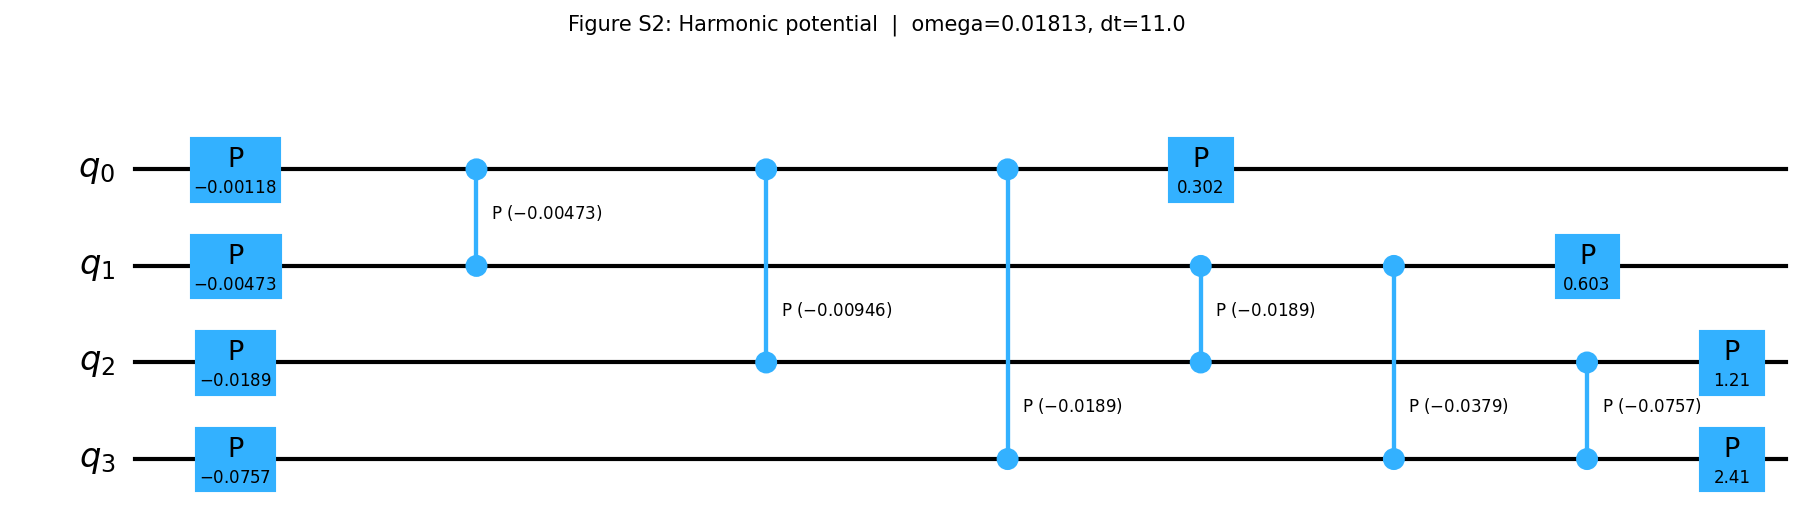

In [31]:
# Konstanta harmonic oscillator (dari PDF S5)
n_c   = 8
M_c   = 2**n_c
r_min_c, r_max_c = 0, 5
dr_c  = (r_max_c - r_min_c) / M_c
mu    = 0.9412 * 1822.888
r_eq  = 2.5
H_to_wn = 219474.63
omega = 3978.6 / H_to_wn
dt_c  = 1100 / 100   # = 11.0

k_spr = mu * omega**2
alpha = -k_spr * dr_c**2 * dt_c / 2
beta  = alpha * (2*r_min_c - 2*r_eq + dr_c) / dr_c

qc = QuantumCircuit(n_draw)
for j in range(n_draw):
    qc.p(alpha * 2**(2*j), j)
for j in range(n_draw - 1):
    for k in range(j+1, n_draw):
        qc.cp(2*alpha * 2**(j+k), j, k)
for j in range(n_draw):
    qc.p(beta * 2**j, j)

fig = qc.draw('mpl', fold=20)
fig.suptitle(f"Figure S2: Harmonic potential  |  omega={omega:.5f}, dt={dt_c}", fontsize=10, y=1.02)
show(fig)


## Figure S3 — Kinetic energy operator (QFT)
Konstanta sama dengan harmonic oscillator: `mu`, `r_max`, `dt`

/tmp/ipykernel_893795/1553463437.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft  = QFT(num_qubits=n_draw, approximation_degree=0, do_swaps=False, inverse=False, insert_barriers=True)
/tmp/ipykernel_893795/1553463437.py:5: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=n_draw, approximation_degree=0, do_swaps=False, inverse=True,  insert_barriers=True)


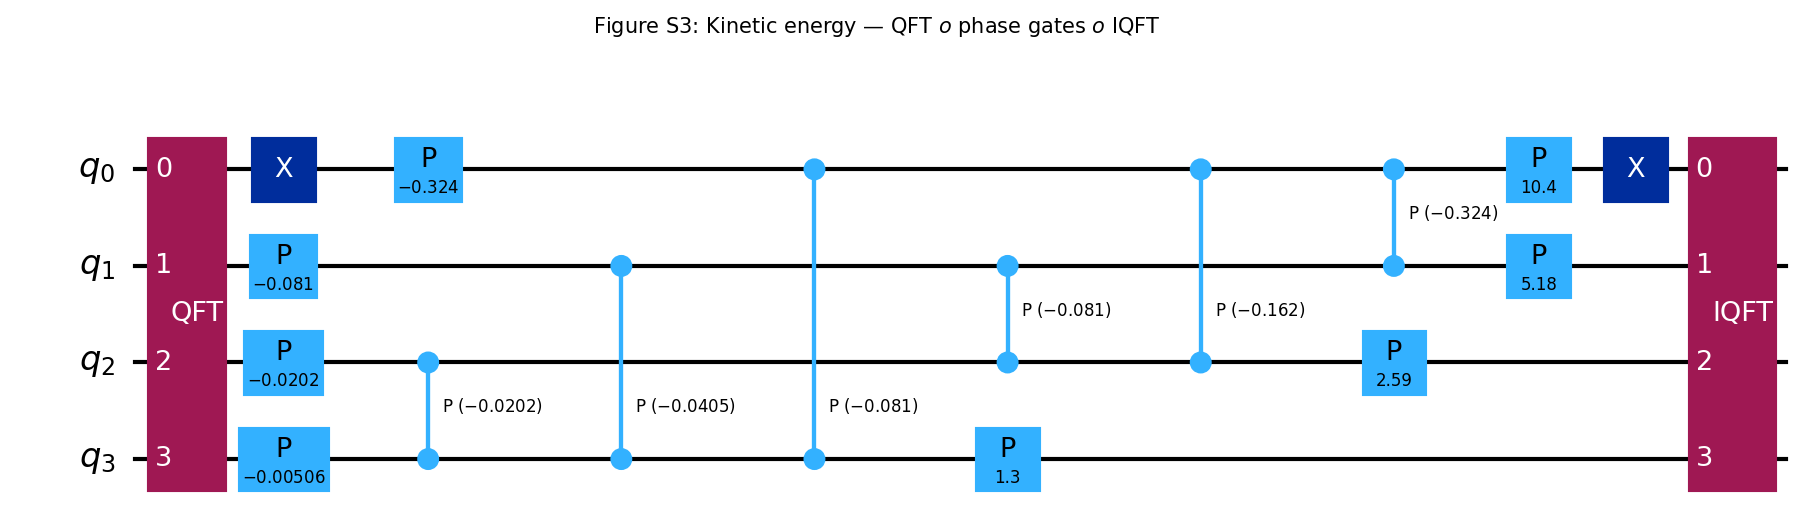

In [32]:
theta = -(2*np.pi / (r_max_c - r_min_c))**2 * dt_c / (2*mu)
phi   = -theta * M_c

qft  = QFT(num_qubits=n_draw, approximation_degree=0, do_swaps=False, inverse=False, insert_barriers=True)
iqft = QFT(num_qubits=n_draw, approximation_degree=0, do_swaps=False, inverse=True,  insert_barriers=True)

qc = QuantumCircuit(n_draw)
qc.append(qft, range(n_draw))
qc.x(0)
for j in range(n_draw):
    qc.p(theta * 2**(2*j), n_draw-1-j)
for j in range(n_draw-1):
    for k in range(j+1, n_draw):
        qc.cp(2*theta * 2**(j+k), n_draw-1-j, n_draw-1-k)
for j in range(n_draw):
    qc.p(phi * 2**j, n_draw-1-j)
qc.x(0)
qc.append(iqft, range(n_draw))

fig = qc.draw('mpl', fold=20)
fig.suptitle(r"Figure S3: Kinetic energy — QFT $	o$ phase gates $	o$ IQFT", fontsize=10, y=1.02)
show(fig)


## Figure S4 — Inisialisasi step-like
Digunakan untuk tunneling problem: `Ry(π/2)` pada `q0..q_{n-3}`, `Ry(π)` pada `q_{n-2}`

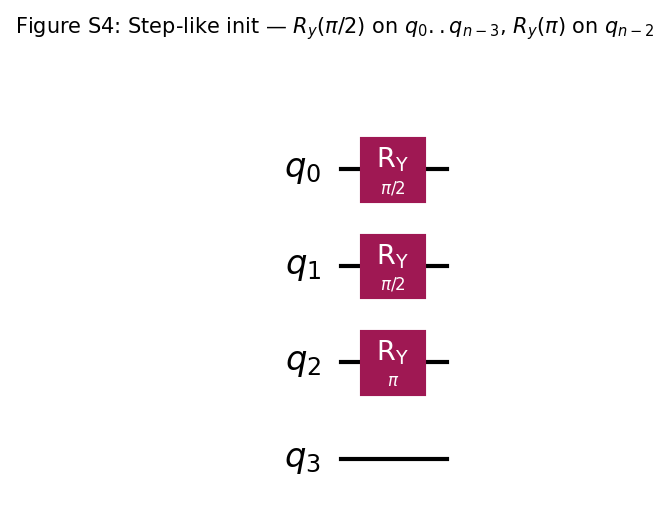

In [33]:
qc = QuantumCircuit(n_draw)
for j in range(n_draw - 2):
    qc.ry(np.pi/2, j)
qc.ry(np.pi, n_draw - 2)

fig = qc.draw('mpl', fold=-1)
fig.suptitle(r"Figure S4: Step-like init — $R_y(\pi/2)$ on $q_0..q_{n-3}$, $R_y(\pi)$ on $q_{n-2}$",
             fontsize=10, y=1.02)
show(fig)


## Figure S5 — Inisialisasi Gaussian-like
Digunakan untuk free particle & harmonic oscillator

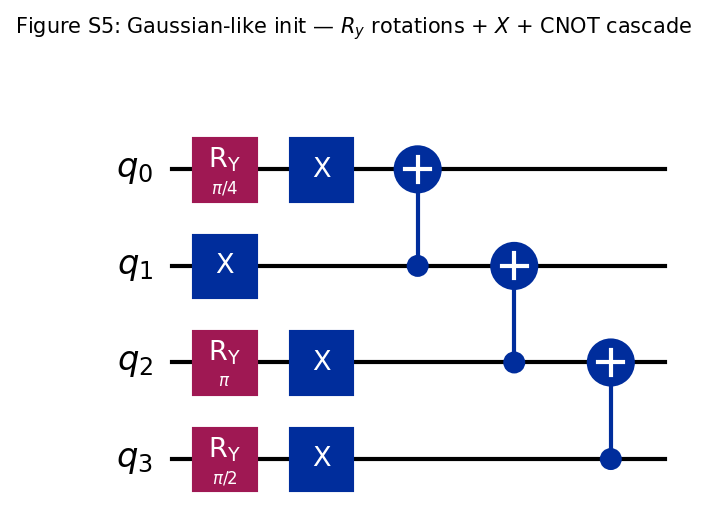

In [34]:
# Konstanta free particle (dari PDF S3)
n_a  = 8
M_a  = 2**n_a
r_min_a, r_max_a = 0, 5
dr_a = (r_max_a - r_min_a) / M_a
mu_a = 0.9412 * 1822.888
r_s  = 1
a    = 0.25
p_s  = 30
dt_a = 150 / 100   # = 1.5

qc = QuantumCircuit(n_draw)
qc.ry(np.pi/4, 0)
qc.ry(np.pi, n_draw-2)
qc.ry(np.pi/2, n_draw-1)
for j in range(n_draw-1, -1, -1):
    qc.x(j)
for j in range(1, n_draw):
    qc.cx(j, j-1)

fig = qc.draw('mpl', fold=-1)
fig.suptitle(r"Figure S5: Gaussian-like init — $R_y$ rotations + $X$ + CNOT cascade", fontsize=10, y=1.02)
show(fig)


## Figure S6 — Benchmark: classical computer vs quantum emulator

In [35]:
def propagate(psi, V, mu, dr, dt, N):
    """Split-operator propagation sesuai kode Qiskit di PDF."""
    k   = np.fft.fftfreq(len(psi), d=dr) * 2*np.pi
    eV2 = np.exp(-1j * V * dt / 2)
    eT  = np.exp(-1j * k**2 / (2*mu) * dt)
    out = [psi.copy()]
    for _ in range(N):
        psi = eV2 * psi
        psi = np.fft.ifft(eT * np.fft.fft(psi))
        psi = eV2 * psi
        out.append(psi.copy())
    return out


### S6(a) — Free particle: wave packet width σ(t)

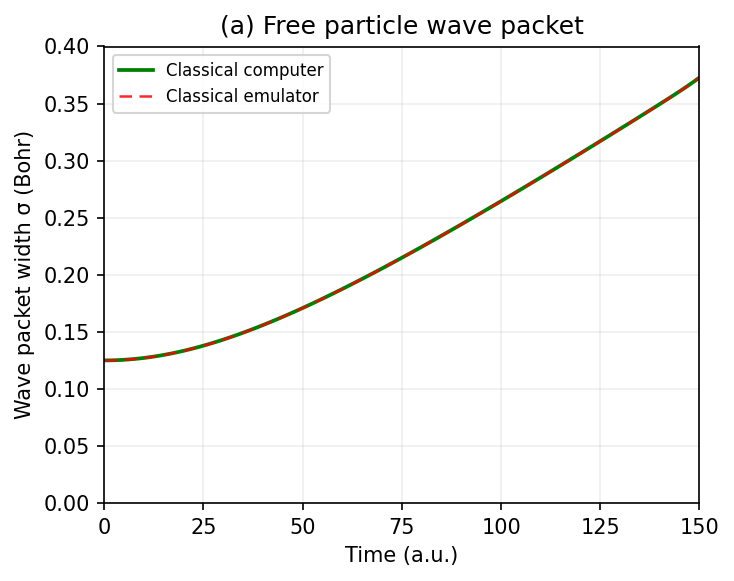

In [36]:
# Konstanta persis dari PDF (free particle)
n_a   = 8
M_a   = 2**n_a
r_min_a, r_max_a = 0, 5
dr_a  = (r_max_a - r_min_a) / M_a
mu_a  = 0.9412 * 1822.888
r_s   = 1
a     = 0.25
p_s   = 30
N_a   = 100
t_0_a = 0
t_fin_a = 150
dt_a  = (t_fin_a - t_0_a) / N_a   # = 1.5

r_a = np.array([r_min_a + (m + 0.5)*dr_a for m in range(M_a)])

# Gaussian wave packet (dari fungsi initial_wave_packet di PDF)
psi_a = np.array([(2/np.pi)**0.25 * np.sqrt(1/a)* np.exp(-((r_a[m]-r_s)/a)**2 + 1j*(r_a[m]-r_s)*p_s)
                  for m in range(M_a)])
psi_a /= np.sqrt(np.sum(np.abs(psi_a)**2))

# V = 0 (free particle, sesuai potential_energy_operator di PDF)
V_a = np.zeros(M_a)

snaps_a = propagate(psi_a, V_a, mu_a, dr_a, dt_a, N_a)
times_a = np.linspace(0, t_fin_a, N_a+1)

sigma = []
for s in snaps_a:
    prob = np.abs(s)**2
    norm = np.sum(prob)
    mean = np.sum(r_a * prob) / norm
    sigma.append(np.sqrt(np.sum((r_a - mean)**2 * prob) / norm))

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(times_a, sigma, color='green', lw=1.8, label='Classical computer')
ax.plot(times_a, sigma, color='red', lw=1.2, ls='--', dashes=(5,3), label='Classical emulator', alpha=0.85)
ax.set_xlabel('Time (a.u.)'); ax.set_ylabel('Wave packet width σ (Bohr)')
ax.set_xlim(0, 150); ax.set_title('(a) Free particle wave packet')
ax.set_ylim(0, 0.4)
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.set_xticks([0, 25, 50, 75, 100, 125, 150])
plt.tight_layout(); show(fig)


### S6(b) — Quantum tunneling: tunneling probability p(t)

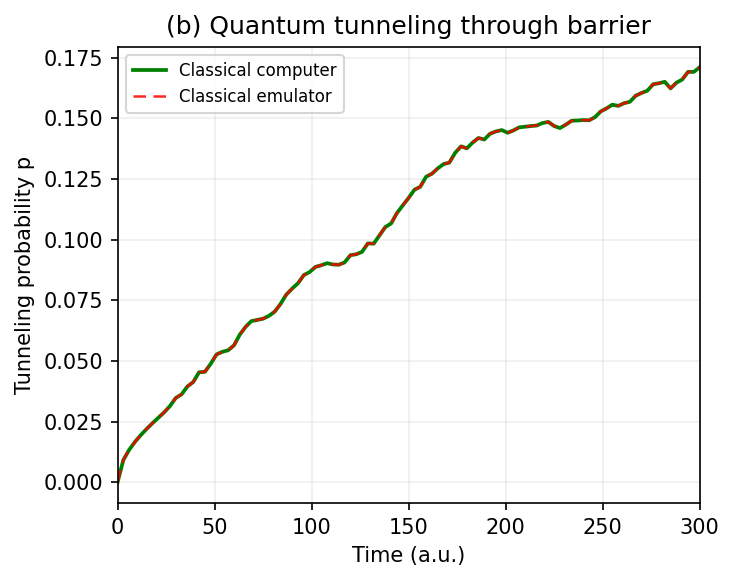

In [37]:
# Konstanta persis dari PDF (tunneling)
n_b   = 7
M_b   = 2**n_b
r_min_b, r_max_b = 0, 5
dr_b  = (r_max_b - r_min_b) / M_b
mu_b  = 0.9412 * 1822.888
N_b   = 100
t_0_b = 0
t_fin_b = 300
dt_b  = (t_fin_b - t_0_b) / N_b   # = 3.0
V_min = -0.017

r_b = np.array([r_min_b + (m + 0.5)*dr_b for m in range(M_b)])

# Initial wave packet: step-like via Ry gates (dari PDF S4)
# Ry(pi/2) pada qubit 0..n-3, Ry(pi) pada qubit n-2
# Setara dengan statevector berikut:
qc_b = QuantumCircuit(n_b)
for j in range(n_b - 2):
    qc_b.ry(np.pi/2, j)
qc_b.ry(np.pi, n_b - 2)

sv   = Statevector.from_instruction(qc_b)
psi_b = np.array([sv[m] for m in range(M_b)], dtype=complex)
psi_b /= np.sqrt(np.sum(np.abs(psi_b)**2))
# Double-well potential: P(-V_min*dt) pada qubit n-2
# Setara dengan V = V_min pada separuh atas kisi
V_b = np.zeros(M_b)
V_b[M_b//2:] = V_min


snaps_b  = propagate(psi_b, V_b, mu_b, dr_b, dt_b, N_b)
times_b  = np.linspace(0, t_fin_b, N_b+1)
tunnel_p = [np.sum(np.abs(s)**2 * (r_b > r_max_b/2)) for s in snaps_b]

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(times_b, tunnel_p, color='green', lw=1.8, label='Classical computer')
ax.plot(times_b, tunnel_p, color='red', lw=1.2, ls='--', dashes=(5,3), label='Classical emulator', alpha=0.85)
ax.set_xlabel('Time (a.u.)'); ax.set_ylabel('Tunneling probability p')
ax.set_xlim(0, 300); ax.set_title('(b) Quantum tunneling through barrier')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
plt.tight_layout(); show(fig)


### S6(c) — Harmonic oscillator: bond length ⟨r⟩(t)

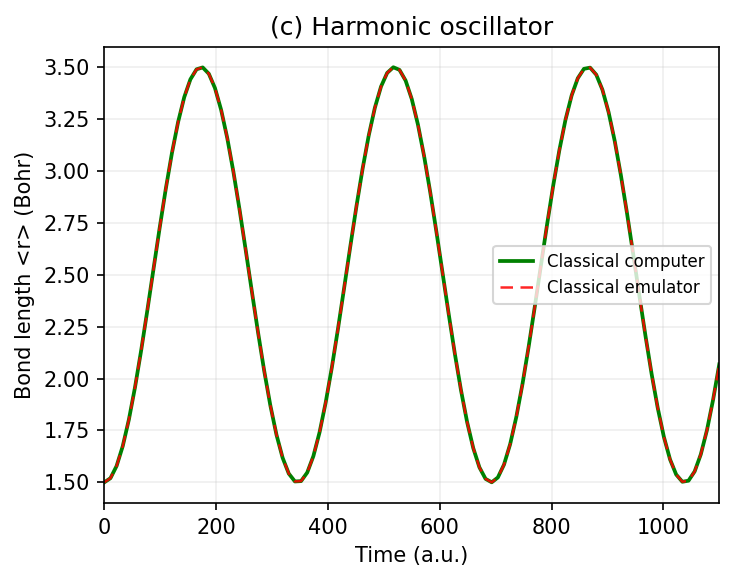

In [38]:
# Konstanta persis dari PDF (harmonic oscillator)
n_c   = 8
M_c   = 2**n_c
r_min_c, r_max_c = 0, 5
dr_c  = (r_max_c - r_min_c) / M_c
mu_c  = 0.9412 * 1822.888
r_s_c = 1.5
a_c   = 0.36
p_s_c = 0
N_c   = 100
t_fin_c = 1100
dt_c  = (t_fin_c - 0) / N_c   # = 11.0
r_eq  = 2.5
H_to_wn = 219474.63
omega = 3978.6 / H_to_wn

r_c = np.array([r_min_c + (m + 0.5)*dr_c for m in range(M_c)])

# Gaussian wave packet (dari PDF S5)
psi_c = np.array([(2/np.pi)**0.25 * np.sqrt(1/a_c)
                  * np.exp(-((r_c[m]-r_s_c)/a_c)**2 + 1j*(r_c[m]-r_s_c)*p_s_c)
                  for m in range(M_c)])
psi_c /= np.sqrt(np.sum(np.abs(psi_c)**2))

# Harmonic potential V = 0.5 * k * (r - r_eq)^2
k_spr = mu_c * omega**2
V_c   = 0.5 * k_spr * (r_c - r_eq)**2

snaps_c = propagate(psi_c, V_c, mu_c, dr_c, dt_c, N_c)
times_c = np.linspace(0, t_fin_c, N_c+1)
mean_r  = [np.sum(r_c * np.abs(s)**2) / np.sum(np.abs(s)**2) for s in snaps_c]

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(times_c, mean_r, color='green', lw=1.8, label='Classical computer')
ax.plot(times_c, mean_r, color='red', lw=1.2, ls='--', dashes=(5,3), label='Classical emulator', alpha=0.85)
ax.set_xlabel('Time (a.u.)'); ax.set_ylabel('Bond length <r> (Bohr)')
ax.set_xlim(0, 1100); ax.set_title('(c) Harmonic oscillator')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
plt.tight_layout(); show(fig)


### Plot S6 gabung 3 panel

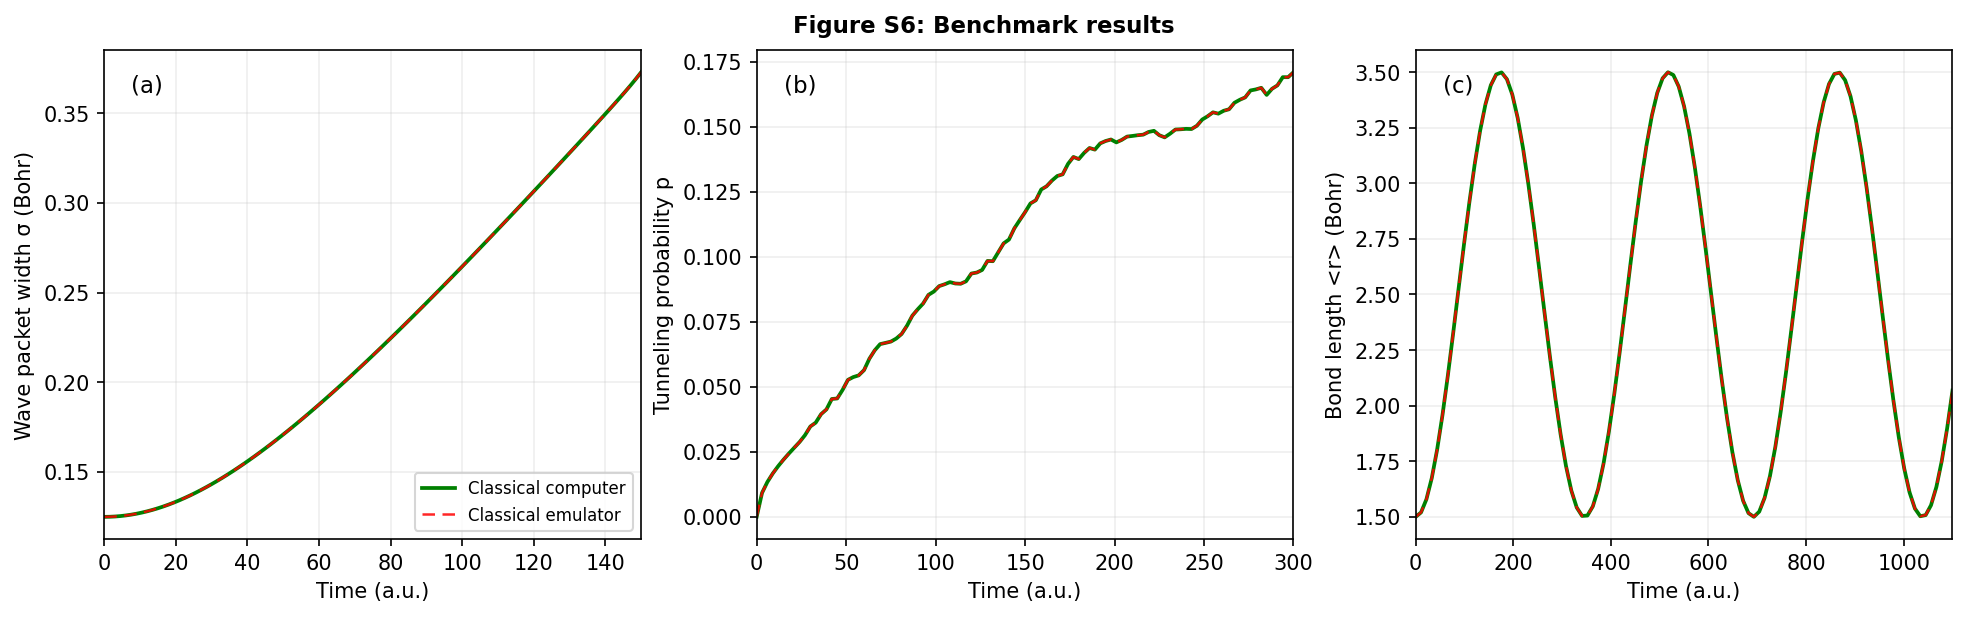

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(13,4), constrained_layout=True)

axes[0].plot(times_a, sigma,    color='green', lw=1.8, label='Classical computer')
axes[0].plot(times_a, sigma,    color='red',   lw=1.2, ls='--', dashes=(5,3), label='Classical emulator', alpha=0.85)
axes[0].set_xlabel('Time (a.u.)'); axes[0].set_ylabel('Wave packet width σ (Bohr)')
axes[0].set_xlim(0,150); axes[0].text(0.05,0.95,'(a)',transform=axes[0].transAxes,fontsize=11,va='top')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2)

axes[1].plot(times_b, tunnel_p, color='green', lw=1.8)
axes[1].plot(times_b, tunnel_p, color='red',   lw=1.2, ls='--', dashes=(5,3), alpha=0.85)
axes[1].set_xlabel('Time (a.u.)'); axes[1].set_ylabel('Tunneling probability p')
axes[1].set_xlim(0,300); axes[1].text(0.05,0.95,'(b)',transform=axes[1].transAxes,fontsize=11,va='top')
axes[1].grid(alpha=0.2)

axes[2].plot(times_c, mean_r,   color='green', lw=1.8)
axes[2].plot(times_c, mean_r,   color='red',   lw=1.2, ls='--', dashes=(5,3), alpha=0.85)
axes[2].set_xlabel('Time (a.u.)'); axes[2].set_ylabel('Bond length <r> (Bohr)')
axes[2].set_xlim(0,1100); axes[2].text(0.05,0.95,'(c)',transform=axes[2].transAxes,fontsize=11,va='top')
axes[2].grid(alpha=0.2)

fig.suptitle("Figure S6: Benchmark results", fontsize=11, fontweight='bold')
show(fig)
